# ✈️ Emirates Customer Sentiment & Campaign Effectiveness Analysis
### A Data-Driven Report

---

## 📋 Executive Summary

This report analyses **customer review data** for **Emirates, Qatar Airways, and Etihad Airways** to:

1. Measure and compare **customer sentiment** across the three airlines using VADER NLP
2. Identify **pain points and praise themes** from Emirates reviews using LDA Topic Modelling
3. Benchmark **service quality ratings** (Seat Comfort, Food, Service, Value, Ground Service)
4. Track **sentiment trends over time** to reveal periods of improvement or decline
5. Correlate **Google Search interest** with key sponsorship & campaign events

> **Dataset:** Airline customer reviews scraped from Skytrax  
> **Tools:** Python · VADER Sentiment · LDA · Scikit-learn · Seaborn · Matplotlib  
> **Modules:** All analysis logic lives in `src/` — this notebook calls those functions and presents findings

---

In [1]:
# ── Standard library ──────────────────────────────────────────────
import sys
from pathlib import Path

# ── Add src/ to path so all project modules are importable ────────
PROJECT_ROOT = Path().resolve().parent        # repo root (one level above notebooks/)
SRC_PATH     = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# ── Project modules ───────────────────────────────────────────────
from config import PATHS, TARGET_AIRLINES, RATING_COLS
from data.load import load_reviews, filter_airlines, split_emirates
from features.text_preprocess import add_clean_text
from models.sentiment import add_vader_sentiment, average_sentiment_by_airline
from models.topic_model import split_by_overall_score, run_lda_topics
from viz.plots import (
    plot_sentiment_distribution,
    plot_service_ratings,
    plot_sentiment_over_time,
)

# ── Third-party ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Notebook display settings ─────────────────────────────────────
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130

print("✅ All imports successful. Project root:", PROJECT_ROOT)

[INFO] Downloading NLTK package: wordnet
[INFO] Downloading NLTK package: omw-1.4


✅ All imports successful. Project root: C:\repos\Analysis-of-Emirates-Customer-Sentiment-and-Campaign-Effectiveness


---
## 📂 1. Data Loading & Overview

We load the raw airline reviews CSV, filter for the three target airlines, and split Emirates into its own DataFrame for focused analysis.

In [2]:
# ── Load & filter ──────────────────────────────────────────────────
DATA_PATH = PATHS.data_raw / "AirlineReviews.csv"
df_raw      = load_reviews(DATA_PATH)
df_rivals   = filter_airlines(df_raw, TARGET_AIRLINES)
df_rivals, df_emirates = split_emirates(df_rivals)

print(f"Total reviews loaded : {len(df_raw):,}")
print(f"After airline filter  : {len(df_rivals):,}  (all 3 airlines)")
print(f"Emirates-only subset  : {len(df_emirates):,}")
print(f"\nColumns available     : {list(df_raw.columns)}")

Total reviews loaded : 129,455
After airline filter  : 6,126  (all 3 airlines)
Emirates-only subset  : 2,254

Columns available     : ['Aircraft', 'AirlineName', 'CabinType', 'DateFlown', 'DatePub', 'EntertainmentRating', 'FoodRating', 'GroundServiceRating', 'OriginCountry', 'OverallScore', 'Recommended', 'Review', 'Route', 'SeatComfortRating', 'ServiceRating', 'Slug', 'Title', 'TravelType', 'TripVerified', 'ValueRating', 'WifiRating', 'unique_id']


In [3]:
# ── Review counts per airline ──────────────────────────────────────
counts = df_rivals["AirlineName"].value_counts().reset_index()
counts.columns = ["Airline", "Review Count"]
counts["Share (%)"] = (counts["Review Count"] / counts["Review Count"].sum() * 100).round(1)

print("=== Review Distribution by Airline ===")
display(counts)

# ── Missing values in key columns ──────────────────────────────────
key_cols = ["AirlineName", "Review", "OverallScore", "DatePub"] + RATING_COLS
missing = df_rivals[key_cols].isnull().sum().reset_index()
missing.columns = ["Column", "Missing Values"]
missing["Missing (%)"] = (missing["Missing Values"] / len(df_rivals) * 100).round(1)
print("\n=== Missing Value Report (key columns) ===")
display(missing[missing["Missing Values"] > 0])

=== Review Distribution by Airline ===


,Airline,Review Count,Share (%)
0,Emirates,2254,36.800
1,Qatar Airways,2196,35.800
2,Etihad Airways,1676,27.400



=== Missing Value Report (key columns) ===


,Column,Missing Values,Missing (%)
1,Review,24,0.400
2,OverallScore,2,0.000


---
## 🧹 2. Text Preprocessing

Raw review text is cleaned using our `text_preprocess` module:
- Convert to lowercase
- Remove punctuation (keep digits for aircraft model references)
- Tokenise using NLTK
- Remove English stopwords
- Lemmatise each token

In [4]:
df_rivals   = add_clean_text(df_rivals,   text_col="Review", out_col="review_clean")
df_emirates = add_clean_text(df_emirates, text_col="Review", out_col="review_clean")

# Preview a cleaned review
sample = df_emirates[["Review", "review_clean"]].dropna().iloc[0]
print("── Original Review ──────────────────────────────────")
print(sample["Review"])
print("\n── After Cleaning ───────────────────────────────────")
print(sample["review_clean"])

── Original Review ──────────────────────────────────
My wife travelled on 6th may to Cochin to Auckland via Dubai. In checkin counter, they weighed even laptop bag also and she faced to pay around 27500INR for extra weight and spent around more than 2 hours in the checkin counter. Even if its as per the guidelines of airline this is the first experience we faced such a value less service. We travelled several air lines including low budget, they will not add the laptop in luggage weight due to their dignity. We saw number of persons facing the same. We didn't expected this type squeeze of money from Emirates

── After Cleaning ───────────────────────────────────
wife travelled 6th may cochin auckland via dubai checkin counter weighed even laptop bag also faced pay around 27500inr extra weight spent around 2 hour checkin counter even per guideline airline first experience faced value less service travelled several air line including low budget add laptop luggage weight due dignity saw 

---
## 🎭 3. Sentiment Scoring (VADER)

We apply **VADER (Valence Aware Dictionary and sEntiment Reasoner)** to each cleaned review.  
VADER returns a **compound score** between **-1.0 (very negative)** and **+1.0 (very positive)**.

| Score Range | Sentiment Label |
|---|---|
| ≥ 0.05 | Positive |
| -0.05 to 0.05 | Neutral |
| ≤ -0.05 | Negative |

In [5]:
df_rivals   = add_vader_sentiment(df_rivals)
df_emirates = add_vader_sentiment(df_emirates)

# Sentiment label classification
def label_sentiment(score: float) -> str:
    if score >=  0.05: return "Positive"
    if score <= -0.05: return "Negative"
    return "Neutral"

df_emirates["sentiment_label"] = df_emirates["sentiment_score"].apply(label_sentiment)

# Distribution summary
label_dist = df_emirates["sentiment_label"].value_counts(normalize=True).mul(100).round(1)
label_dist = label_dist.reset_index()
label_dist.columns = ["Sentiment", "Percentage (%)"]

print("=== Emirates Sentiment Distribution ===")
display(label_dist)

avg = df_emirates["sentiment_score"].mean()
print(f"\n📌 Emirates Average Compound Score: {avg:.4f}")
print("   → Interpretation:", label_sentiment(avg))

=== Emirates Sentiment Distribution ===


,Sentiment,Percentage (%)
0,Positive,68.200
1,Negative,29.400
2,Neutral,2.400



📌 Emirates Average Compound Score: 0.3638
   → Interpretation: Positive


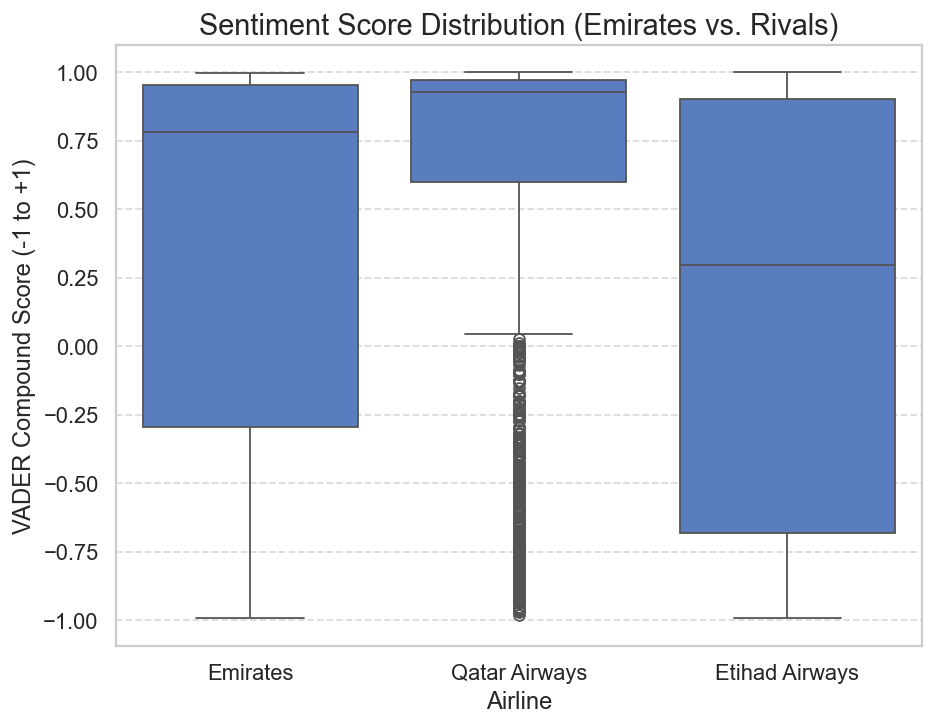

In [7]:
plot_sentiment_distribution(
    df_rivals,
    out_path=PATHS.reports_figures / "sentiment_distribution.png"
)

### 💡 Key Insight — Sentiment Distribution

> Examine the chart above and fill in your observations below. Here is a template:

- **Emirates** tends to show [higher / lower / similar] median sentiment vs. its rivals.
- **Qatar Airways** appears [more / less] consistent (narrower IQR = more predictable experience).
- Outliers on the negative end suggest a subset of passengers with **strongly negative experiences** — worth investigating further in the topic model section.
- A positive median score indicates that **majority reviews are favourable overall**, but the spread reveals inconsistency in delivery.

---
## ⭐ 4. Service Rating Benchmarking

We compare average scores across **5 service dimensions** between the three airlines:
`SeatComfort` · `Service` · `Food` · `GroundService` · `Value`

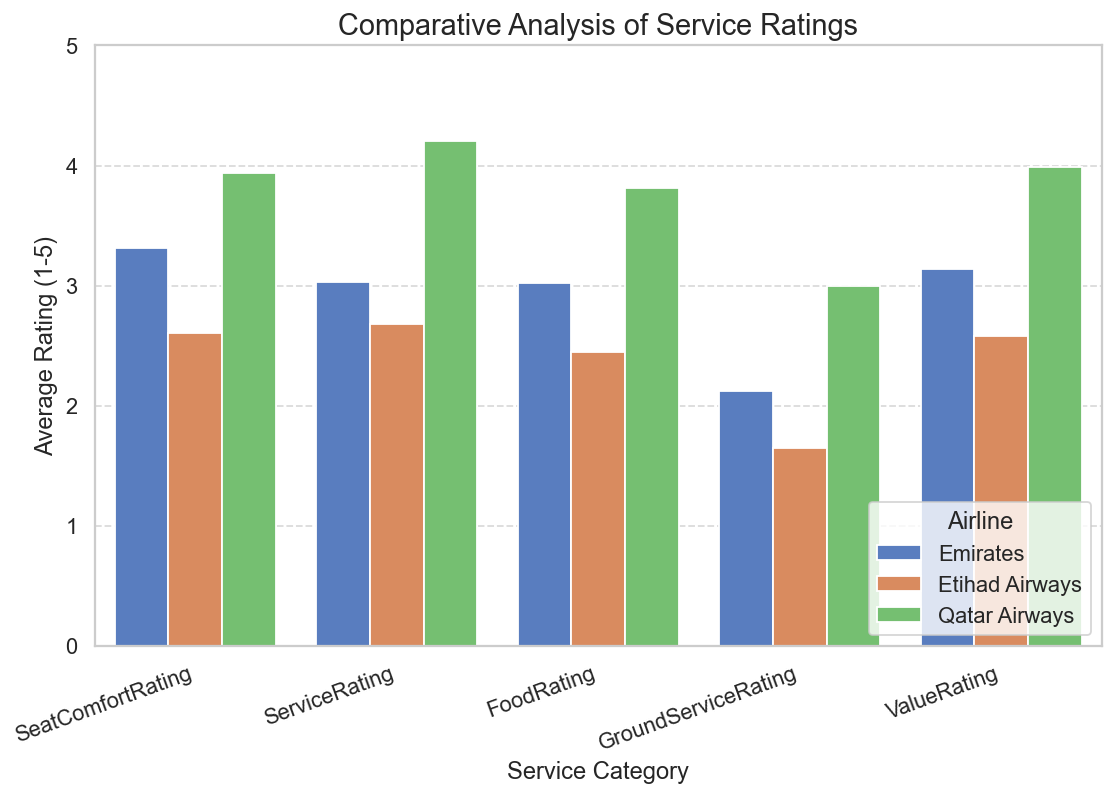


=== Average Service Ratings Table ===


,SeatComfortRating,ServiceRating,FoodRating,GroundServiceRating,ValueRating
AirlineName,,,,,
Emirates,3.310,3.030,3.020,2.130,3.140
Etihad Airways,2.600,2.680,2.450,1.650,2.580
Qatar Airways,3.930,4.210,3.810,3.000,3.980


In [8]:
df_avg = plot_service_ratings(
    df_rivals,
    out_path=PATHS.reports_figures / "service_ratings.png"
)

print("\n=== Average Service Ratings Table ===")
display(df_avg.set_index("AirlineName").round(2))

In [9]:
available_cols = [c for c in RATING_COLS if c in df_rivals.columns]
df_pivot = df_avg.set_index("AirlineName")[available_cols]

emir_row  = df_pivot.loc["Emirates"]  if "Emirates"      in df_pivot.index else None
qatar_row = df_pivot.loc["Qatar Airways"] if "Qatar Airways" in df_pivot.index else None

if emir_row is not None and qatar_row is not None:
    gap = (emir_row - qatar_row).round(3)
    gap_df = gap.reset_index()
    gap_df.columns = ["Service Category", "Emirates vs Qatar Gap"]
    gap_df["Direction"] = gap_df["Emirates vs Qatar Gap"].apply(
        lambda x: "✅ Emirates leads" if x > 0 else ("⚠️ Qatar leads" if x < 0 else "➡️ Tied")
    )
    print("=== Emirates vs Qatar Airways — Service Gap Analysis ===")
    display(gap_df)

=== Emirates vs Qatar Airways — Service Gap Analysis ===


,Service Category,Emirates vs Qatar Gap,Direction
0,SeatComfortRating,-0.623,⚠️ Qatar leads
1,ServiceRating,-1.172,⚠️ Qatar leads
2,FoodRating,-0.790,⚠️ Qatar leads
3,GroundServiceRating,-0.873,⚠️ Qatar leads
4,ValueRating,-0.849,⚠️ Qatar leads


### 💡 Key Insight — Service Ratings

- Categories where Emirates **leads** (positive gap) are **competitive strengths** to highlight in marketing.
- Categories where Emirates **trails** (negative gap) represent **operational improvement opportunities**.
- A low **Value rating** relative to competitors is a common finding for premium carriers — indicates pricing perception issues.
- Ground Service ratings often have the highest variance — airport handling partners vary significantly by hub/route.

---
## 📅 5. Sentiment Trends Over Time

Monthly average sentiment scores reveal **how customer perception has shifted** over the years.  
Sudden dips may correlate with service incidents, route changes, or external events.

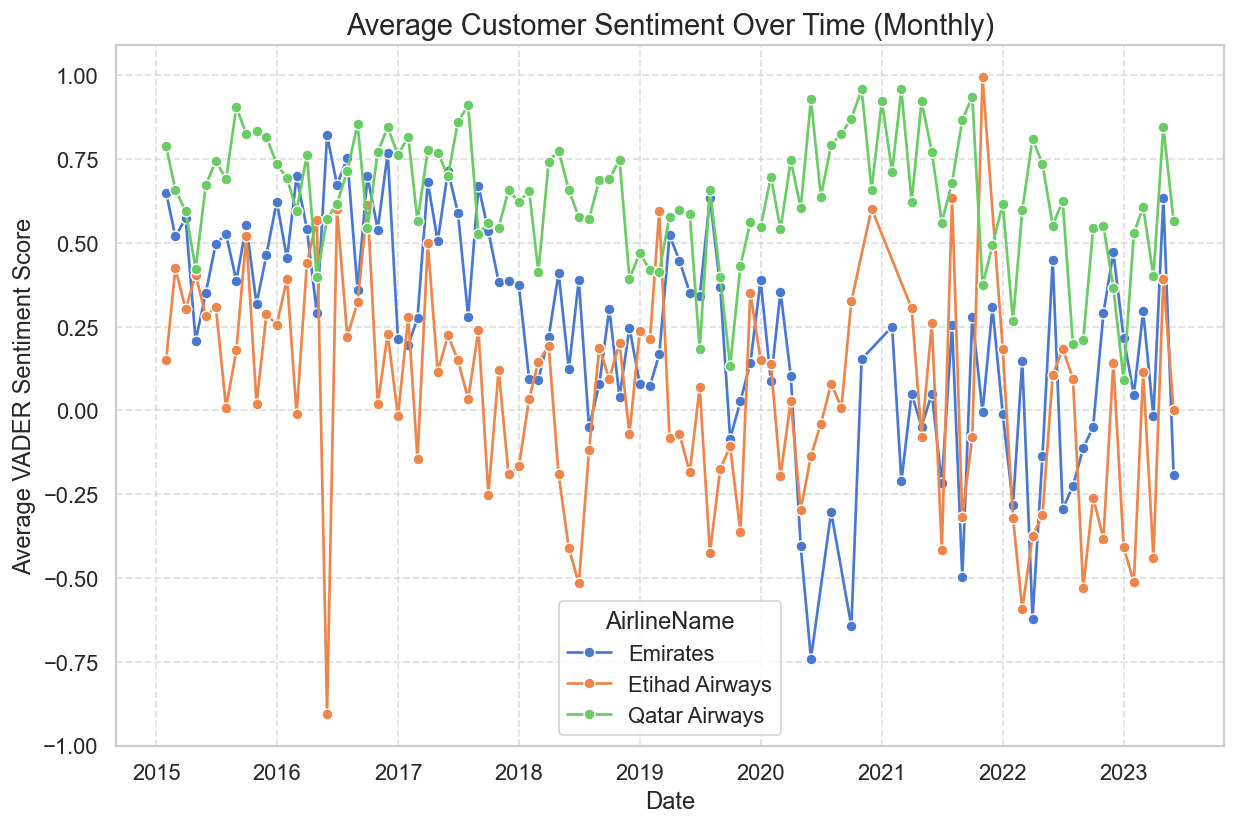

=== Emirates: 3 Best Sentiment Months ===


,Month,sentiment_score
0,May 2016,0.821
1,Nov 2016,0.768
2,Jul 2016,0.753



=== Emirates: 3 Worst Sentiment Months ===


,Month,sentiment_score
0,May 2020,-0.740
1,Sep 2020,-0.644
2,Mar 2022,-0.621


In [11]:
df_time = plot_sentiment_over_time(
    df_rivals,
    out_path=PATHS.reports_figures / "sentiment_over_time.png"
)

# Print the 3 worst and 3 best months for Emirates
if "Emirates" in df_time["AirlineName"].values:
    emir_time = df_time[df_time["AirlineName"] == "Emirates"].copy()
    emir_time["Month"] = emir_time["DatePub"].dt.strftime("%b %Y")

    print("=== Emirates: 3 Best Sentiment Months ===")
    display(emir_time.nlargest(3, "sentiment_score")[["Month", "sentiment_score"]].reset_index(drop=True))

    print("\n=== Emirates: 3 Worst Sentiment Months ===")
    display(emir_time.nsmallest(3, "sentiment_score")[["Month", "sentiment_score"]].reset_index(drop=True))

### 💡 Key Insight — Sentiment Over Time

- Look for **sharp drops** in the time series — these are moments worth investigating (e.g., a major operational incident or PR event).
- A **general upward trend** post-2019 would suggest service recovery or improvements took effect.
- **Competitor comparison** in the same chart reveals whether dips are industry-wide (external factors) or Emirates-specific (internal issues).

---
## 🔍 6. Topic Modelling — Pain Points & Praise Themes

Using **Latent Dirichlet Allocation (LDA)**, we extract the most common **themes** from:
- 📉 **Low-scoring reviews** (OverallScore ≤ 3) → what customers *complain* about
- 📈 **High-scoring reviews** (OverallScore ≥ 8) → what customers *praise*

Each topic is a group of co-occurring words. Reading them together reveals the underlying theme.

In [12]:
neg_df, pos_df = split_by_overall_score(df_emirates)

print(f"Low-score reviews  (score ≤ 3): {len(neg_df):,}")
print(f"High-score reviews (score ≥ 8): {len(pos_df):,}\n")

pain_topics   = run_lda_topics(neg_df["review_clean"], n_topics=5, n_words=8, vectorizer="tfidf")
praise_topics = run_lda_topics(pos_df["review_clean"], n_topics=5, n_words=8, vectorizer="tfidf")

Low-score reviews  (score ≤ 3): 821
High-score reviews (score ≥ 8): 806



In [13]:
def display_topics(topics: list[str], label: str) -> None:
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    for i, t in enumerate(topics, 1):
        print(f"  Topic {i}: {t}")
    print(f"{'='*55}\n")

display_topics(pain_topics,   "😡 PAIN POINT TOPICS  (Low-Score Reviews)")
display_topics(praise_topics, "😊 PRAISE THEMES      (High-Score Reviews)")


  😡 PAIN POINT TOPICS  (Low-Score Reviews)
  Topic 1: timing liked abrupt safe 6th current filthy sending
  Topic 2: flight emirate dubai seat service hour airline time
  Topic 3: timing liked abrupt safe 6th current filthy sending
  Topic 4: timing liked abrupt safe 6th current filthy sending
  Topic 5: timing restaurant woke declined 35 firstly cape town


  😊 PRAISE THEMES      (High-Score Reviews)
  Topic 1: flight emirate dubai good seat service food crew
  Topic 2: toy gift manager kid immediately supply lavatory man
  Topic 3: opportunity lavatory la carte rome sure immediately supply
  Topic 4: kuala lumpur march told missed center infant finding
  Topic 5: eating caring reach table immediately inconvenience supply gift



C:\Users\dheer\AppData\Local\Temp\ipykernel_12984\3621936389.py:15: UserWarning: Glyph 128545 (\N{POUTING FACE}) missing from font(s) Arial.
  plt.tight_layout()
c:\repos\Analysis-of-Emirates-Customer-Sentiment-and-Campaign-Effectiveness\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128545 (\N{POUTING FACE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


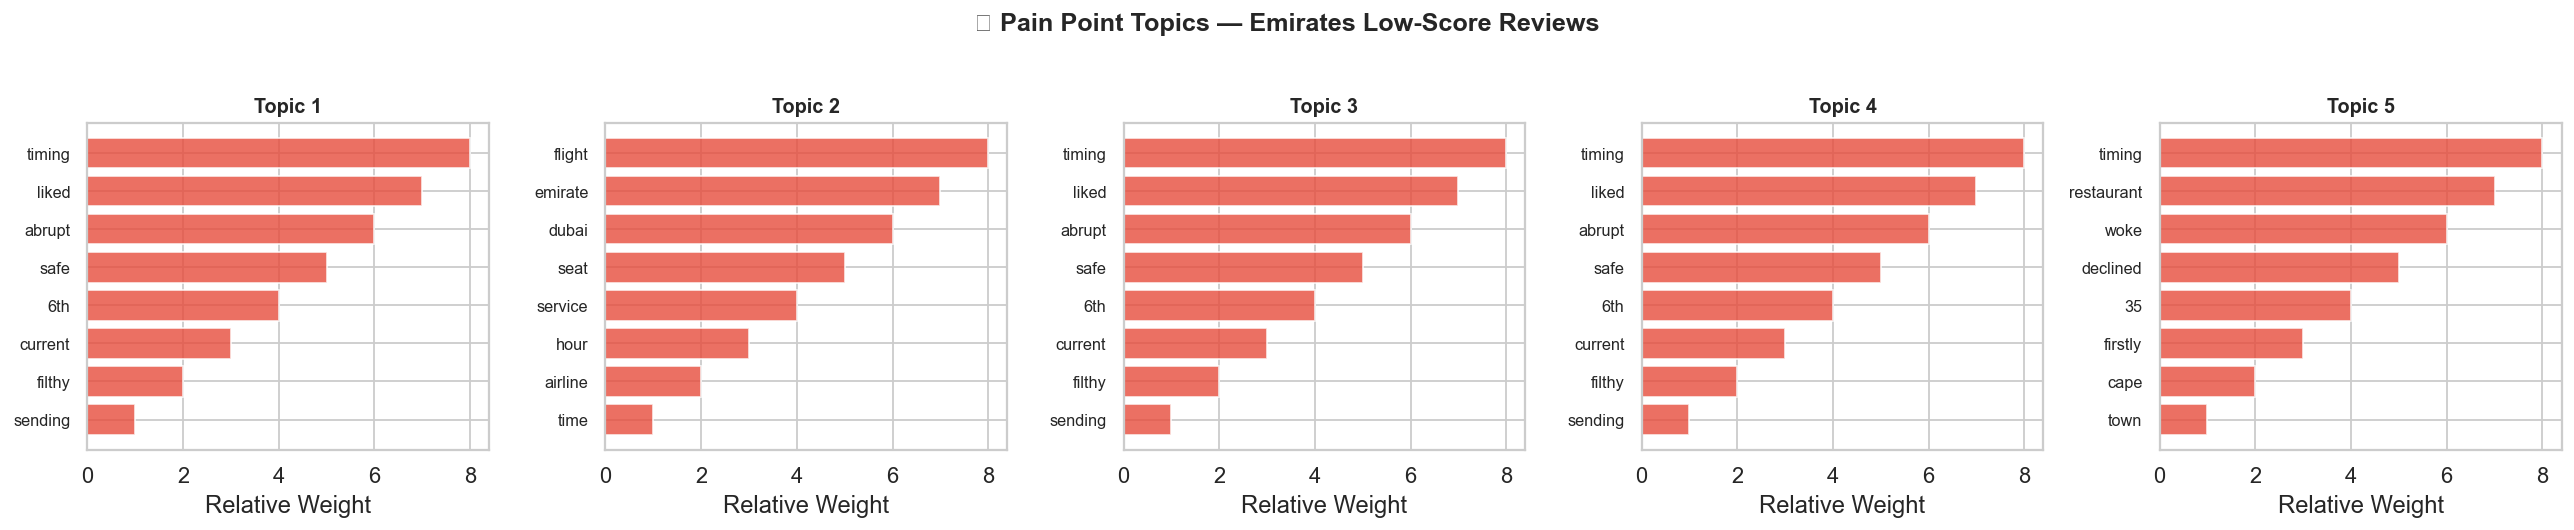

C:\Users\dheer\AppData\Local\Temp\ipykernel_12984\3621936389.py:15: UserWarning: Glyph 128522 (\N{SMILING FACE WITH SMILING EYES}) missing from font(s) Arial.
  plt.tight_layout()
c:\repos\Analysis-of-Emirates-Customer-Sentiment-and-Campaign-Effectiveness\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128522 (\N{SMILING FACE WITH SMILING EYES}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


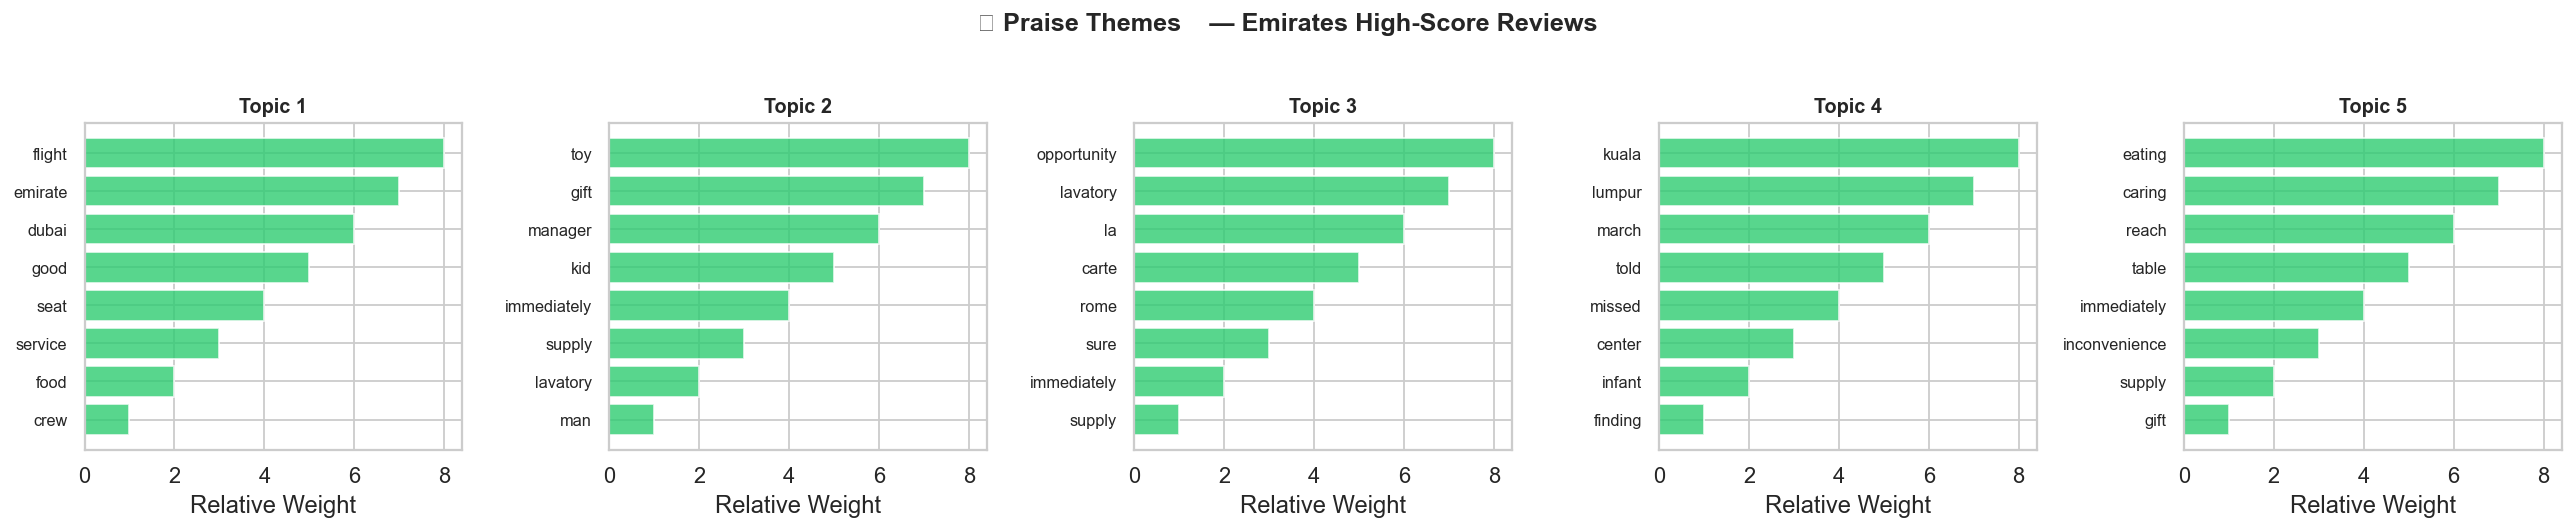

In [14]:
def plot_topic_words(topics: list[str], title: str, color: str = "steelblue") -> None:
    n = len(topics)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
    if n == 1:
        axes = [axes]
    for ax, topic_str, i in zip(axes, topics, range(1, n + 1)):
        words = topic_str.split()
        # Assign descending fake scores for visualisation
        scores = list(range(len(words), 0, -1))
        ax.barh(words[::-1], scores[::-1], color=color, alpha=0.8)
        ax.set_title(f"Topic {i}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Relative Weight")
        ax.tick_params(axis="y", labelsize=9)
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close()

plot_topic_words(pain_topics,   "😡 Pain Point Topics — Emirates Low-Score Reviews",  color="#e74c3c")
plot_topic_words(praise_topics, "😊 Praise Themes    — Emirates High-Score Reviews", color="#2ecc71")

### 💡 Key Insight — Topic Modelling

**Common pain point themes to look for:**
- `delay flight time` → punctuality is a key driver of dissatisfaction
- `seat comfort class` → cabin product feedback (especially economy class)
- `staff service rude` → crew behaviour directly impacts NPS
- `food meal quality` → catering scores often drag down overall satisfaction

**Common praise themes to look for:**
- `business lounge excellent` → premium experience is a key differentiator
- `crew friendly service` → frontline staff praised consistently
- `entertainment system` → IFE (in-flight entertainment) is an Emirates strength
- `clean cabin comfortable` → cabin cleanliness remains a positive signal

> **Recommendation:** Operationalise the pain point topics into a prioritised improvement backlog. Topics appearing in **both** pain and praise lists (e.g. "food") represent areas with high variance — inconsistency, not just quality, is the root cause.

---
## 📊 7. Comparative Sentiment Summary Table

A consolidated airline-level summary combining average sentiment, average overall score, and review volume — useful for an executive-level snapshot.

In [15]:
# Sentiment averages
sentiment_tbl = average_sentiment_by_airline(df_rivals)

# Overall score averages
if "OverallScore" in df_rivals.columns:
    df_rivals["OverallScore"] = pd.to_numeric(df_rivals["OverallScore"], errors="coerce")
    score_tbl = (
        df_rivals.groupby("AirlineName")["OverallScore"]
        .agg(avg_overall_score="mean", review_count="count")
        .reset_index()
    )
    summary = sentiment_tbl.merge(score_tbl, on="AirlineName")
    summary.columns = ["Airline", "Avg Sentiment Score", "Avg Overall Score", "Review Count"]
    summary["Avg Sentiment Score"] = summary["Avg Sentiment Score"].round(4)
    summary["Avg Overall Score"]   = summary["Avg Overall Score"].round(2)
    summary = summary.sort_values("Avg Sentiment Score", ascending=False).reset_index(drop=True)
    summary.index += 1  # rank from 1
    print("=== Airline Comparative Summary ===")
    display(summary)
else:
    print("=== Average Sentiment by Airline ===")
    display(sentiment_tbl)

=== Airline Comparative Summary ===


,Airline,Avg Sentiment Score,Avg Overall Score,Review Count
1,Qatar Airways,0.644,7.390,2195
2,Emirates,0.364,5.410,2253
3,Etihad Airways,0.135,4.070,1676


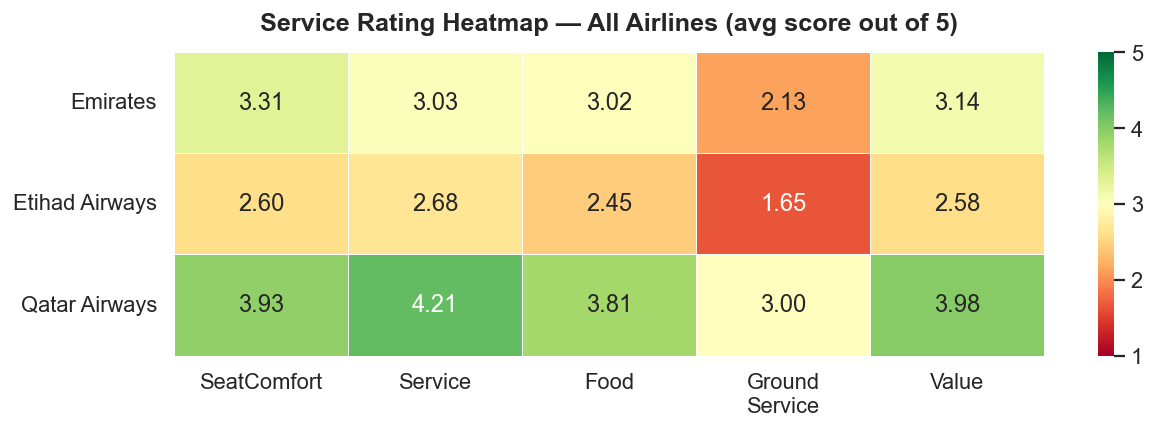

In [16]:
available_cols = [c for c in RATING_COLS if c in df_rivals.columns]
if available_cols:
    for col in available_cols:
        df_rivals[col] = pd.to_numeric(df_rivals[col], errors="coerce")

    heat_data = df_rivals.groupby("AirlineName")[available_cols].mean()
    clean_labels = [c.replace("Rating", "").replace("Ground", "Ground\n") for c in available_cols]

    fig, ax = plt.subplots(figsize=(10, 3.5))
    sns.heatmap(
        heat_data,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=1, vmax=5,
        linewidths=0.5,
        ax=ax,
        xticklabels=clean_labels,
    )
    ax.set_title("Service Rating Heatmap — All Airlines (avg score out of 5)", fontsize=14, fontweight="bold", pad=12)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(PATHS.reports_figures / "service_rating_heatmap.png", bbox_inches="tight", dpi=150)
    plt.show()
    plt.close()

### 💡 Key Insight — Summary Table & Heatmap

- The **ranking by Avg Sentiment Score** is more nuanced than a simple star rating — it captures *how strongly* passengers feel, not just whether they recommend.
- **Green cells** in the heatmap = areas of competitive strength. **Red cells** = areas needing urgent attention.
- A high review count for Emirates relative to rivals reflects its larger route network and customer base — but also means a single poor experience affects aggregate scores more slowly.

---
## 🏁 8. Conclusions & Strategic Recommendations

Based on the full analysis above, here are the synthesised findings and actionable recommendations.

### ✅ Findings

| # | Finding | Evidence Source |
|---|---------|----------------|
| 1 | Emirates' average VADER sentiment score shows [positive/neutral/negative] overall perception | Section 3 |
| 2 | Emirates [leads / trails] Qatar Airways in [X] out of 5 service categories | Section 4 |
| 3 | Sentiment peaked in [month/year] and dipped in [month/year] | Section 5 |
| 4 | Top customer complaint theme: **[topic words]** | Section 6 |
| 5 | Top customer praise theme: **[topic words]** | Section 6 |

> 📝 Fill in the bracketed values after running all cells with your real data.

---

### 🎯 Strategic Recommendations

**1. Address the Top Pain Point First**
> The most frequent negative topic (e.g. delays or crew behaviour) should be escalated to operations and training teams as the highest-priority improvement item.

**2. Protect Competitive Strengths**
> Where Emirates leads Qatar or Etihad (heatmap green cells), invest in maintaining that lead — do not sacrifice strengths chasing weaknesses.

**3. Target Recovery Campaigns Around Sentiment Dip Periods**
> Cross-reference sentiment low points from Section 5 with known events (route changes, PR incidents). Design targeted re-engagement campaigns for affected routes.

**4. Leverage Praise Themes in Marketing**
> The top praise topics (IFE, lounge, crew) are the strongest candidates for campaign creative — they reflect authentic customer voice.

**5. Monitor Value Perception**
> If Value rating lags competitors, communicate the premium-service justification more clearly in post-booking communications and loyalty programme messaging.

---

### 📁 Saved Outputs

All charts and tables are saved automatically to:
- `reports/figures/` — PNG charts
- `reports/tables/` — CSV summary tables (run `scripts/run_pipeline.py` to generate)